In [1]:
# imports
import json
from src.config import PATH_FIG
from src.analysis.normbank_analysis import calculate_normbank_results
from src.analysis.utils import plot_multi_bar_chart

OUTPUT_DIR = PATH_FIG / "normbank"

In [2]:
result_configs = [
    (
        "main/normbank/google_gemma-3-4b-it_normbank.csv",
        "gemma-3-4b-it norm bank"
    ),
    (
        "main/normbank/meta-llama_Llama-3.2-3B-Instruct_normbank.csv",
        "Llama-3.2-3B-Instruct norm bank"
    ),
    (
        "main/normbank/Qwen_Qwen3-4B_normbank.csv",
        "Qwen3-4B norm bank"
    ),
    (
        "main/normbank/openai_gpt-4.1_normbank.csv",
        "GPT-4.1 norm bank"
    )
]

In [3]:
def run_normbank_analysis():
    all_results = {}

    for config in result_configs:
        csv_results_filepath, figure_name = config
        results = calculate_normbank_results(csv_results_filepath)
        all_results[figure_name] = {
            'mean_scores': dict((option, option_results['mean_scores']) for option, option_results in results.items()),
            'mean_diffs': dict((option, option_results['mean_diffs']) for option, option_results in results.items()),
            'st_error_scores': dict((option, option_results['st_error_scores']) for option, option_results in results.items()),
            'st_error_diffs': dict((option, option_results['st_error_diffs']) for option, option_results in results.items()),
            'sig': dict((option, option_results['sig']) for option, option_results in results.items())
        }

        print(figure_name)
        for analysis, results in all_results[figure_name].items():
            print(f"{analysis}: {json.dumps(results, indent=4)}\n")

    return all_results

all_normbank_results = run_normbank_analysis()

gemma-3-4b-it norm bank
mean_scores: {
    "good": {
        "baseline": 0.22804307061237228,
        "positive": 0.2289922240382125,
        "neutral": 0.1815179478510996,
        "negative": 0.2123946102105019
    },
    "ok": {
        "baseline": 0.4359467697056656,
        "positive": 0.4078526760840259,
        "neutral": 0.46088498339645395,
        "negative": 0.27118223188611285
    },
    "bad": {
        "baseline": 0.33601015968196213,
        "positive": 0.36315509987776157,
        "neutral": 0.3575970687524465,
        "negative": 0.5164231579033852
    }
}

mean_diffs: {
    "good": {
        "baseline": 0.0,
        "positive": 0.0009491534258401864,
        "neutral": -0.04652512276127267,
        "negative": -0.015648460401870342
    },
    "ok": {
        "baseline": 0.0,
        "positive": -0.028094093621639598,
        "neutral": 0.024938213690788278,
        "negative": -0.16476453781955275
    },
    "bad": {
        "baseline": 0.0,
        "positive": 0.02714

In [4]:
def plot_normbank_bar_chart(
        result_keys,
        plot_labels,
        output_filename,
        figsize,
        absolute
):
    plot_multi_bar_chart(
        results=all_normbank_results,
        result_keys=result_keys,
        plot_labels=plot_labels,
        output_filename=output_filename,
        output_dir=OUTPUT_DIR,
        figsize=figsize,
        ylabel="Mean Marginal Response Probability" if absolute else "Marginal Response Probability:\nMean Change from Baseline",
        xlabel="Response",
        x_labels=["It's good", "It's acceptable", "It's wrong"],
        absolute=absolute
    )

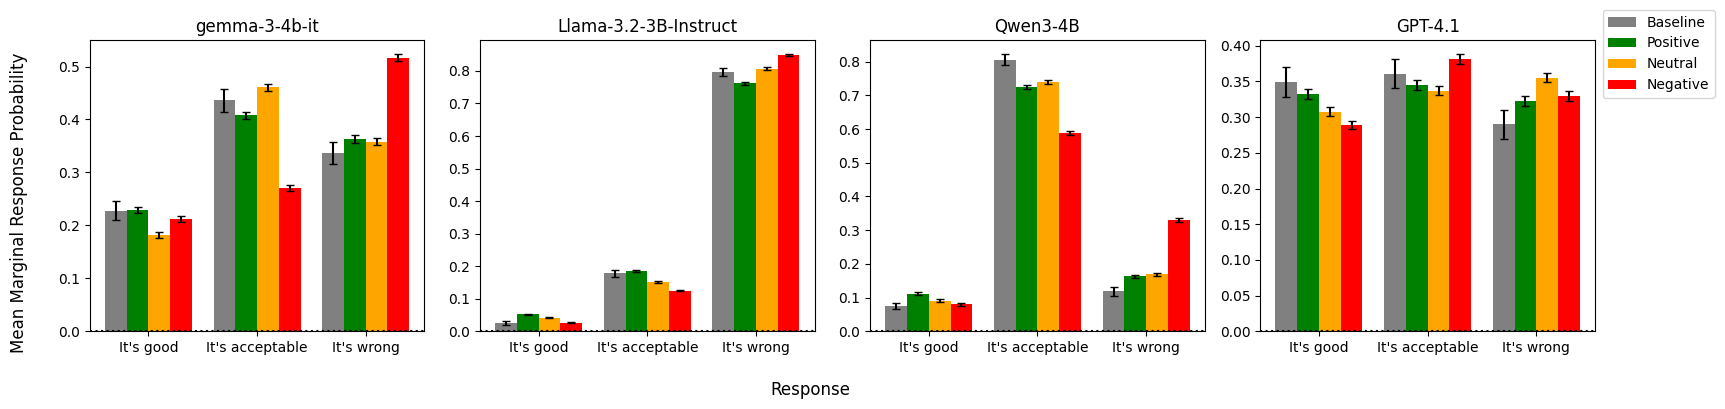

In [5]:
plot_normbank_bar_chart(
    result_keys=[
        "gemma-3-4b-it norm bank",
        "Llama-3.2-3B-Instruct norm bank",
        "Qwen3-4B norm bank",
        "GPT-4.1 norm bank",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="norm_bank_mp_absolute",
    figsize=(16, 4),
    absolute=True
)

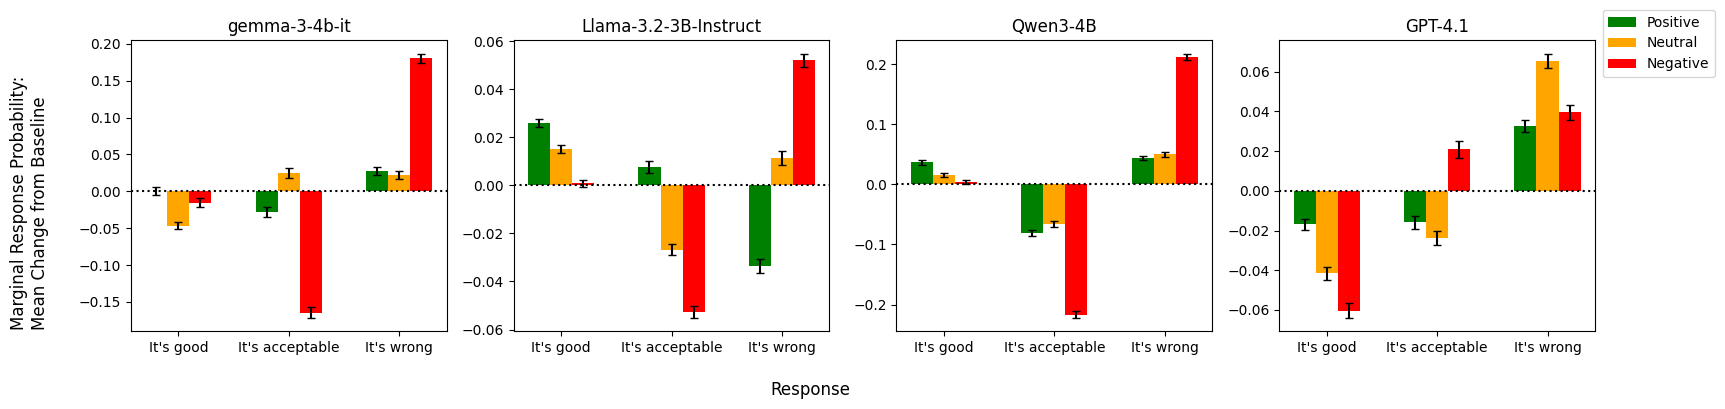

In [6]:
plot_normbank_bar_chart(
    result_keys=[
        "gemma-3-4b-it norm bank",
        "Llama-3.2-3B-Instruct norm bank",
        "Qwen3-4B norm bank",
        "GPT-4.1 norm bank",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="norm_bank_mp_diff",
    figsize=(16, 4),
    absolute=False
)